Epoch 1, Loss: 0.2651
Epoch 2, Loss: 0.0910
Epoch 3, Loss: 0.0709
Epoch 4, Loss: 0.0613
Epoch 5, Loss: 0.0525


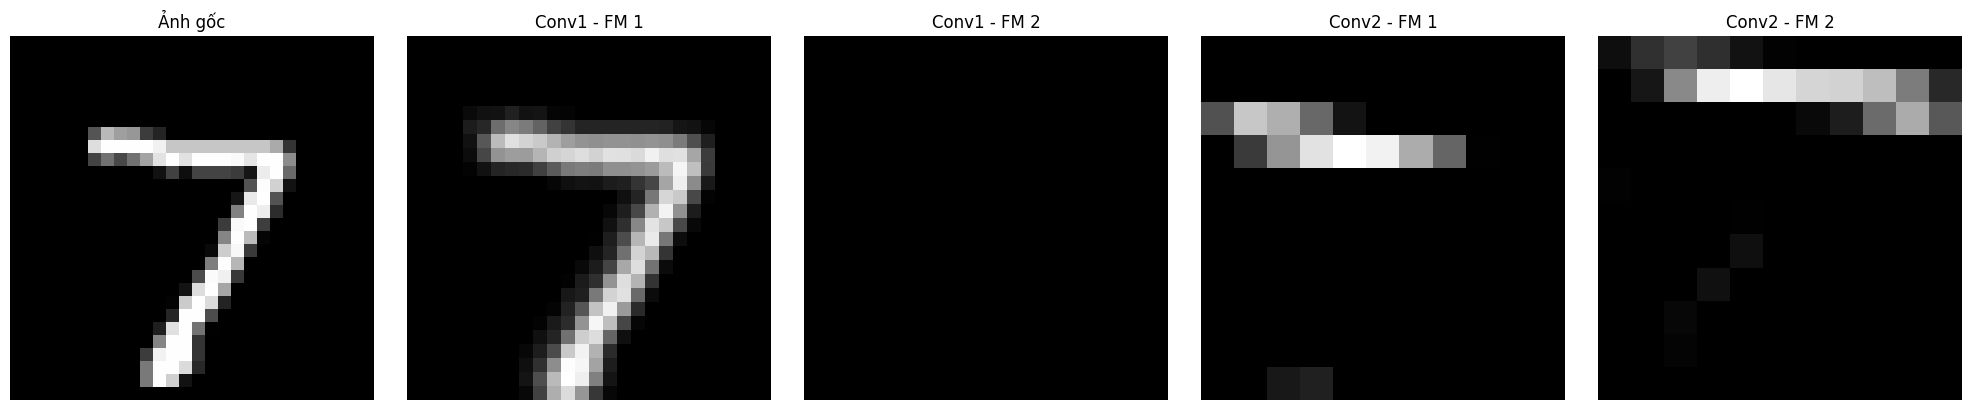

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Định nghĩa mô hình CNN
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = self.fc1(x)
        return x

# Khởi tạo mô hình và load trọng số đã huấn luyện
model = MNIST_CNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Huấn luyện mô hình (5 epoch)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

# 3. Hàm visualize_feature_map đã được sửa theo yêu cầu câu 4
def visualize_feature_map():
    model.eval()
    images, _ = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)
    
    # Tính feature map từ conv1 (16 kênh, kích thước 26x26)
    conv1_output = torch.relu(model.conv1(img))
    # Tính feature map từ conv2 (có qua conv1 + pool + conv2)
    # conv1 -> pool -> conv2 -> relu
    conv2_output = torch.relu(model.conv2(model.pool(torch.relu(model.conv1(img)))))
    
    # Vẽ 5 cột: ảnh gốc + 2 feature map conv1 + 2 feature map conv2
    plt.figure(figsize=(20, 4))  # Tăng kích thước lên 20x4 cho 5 cột
    
    # Cột 1: Ảnh gốc
    plt.subplot(1, 5, 1)
    plt.title("Ảnh gốc")
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.axis('off')
    
    # Cột 2: Feature map 1 từ conv1
    plt.subplot(1, 5, 2)
    plt.title("Conv1 - FM 1")
    plt.imshow(conv1_output[0, 0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    # Cột 3: Feature map 2 từ conv1
    plt.subplot(1, 5, 3)
    plt.title("Conv1 - FM 2")
    plt.imshow(conv1_output[0, 1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    # Cột 4: Feature map 1 từ conv2
    plt.subplot(1, 5, 4)
    plt.title("Conv2 - FM 1")
    plt.imshow(conv2_output[0, 0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    # Cột 5: Feature map 2 từ conv2
    plt.subplot(1, 5, 5)
    plt.title("Conv2 - FM 2")
    plt.imshow(conv2_output[0, 1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Gọi hàm visualize_feature_map
visualize_feature_map()

## Giải thích câu 4: So sánh feature map giữa các tầng

### 1. Feature map từ tầng conv1 có đặc điểm gì?

- **Kích thước lớn hơn**: 26x26 pixel
- **Nhận diện được hình dạng**: Vẫn còn thấy được "bóng dáng" của chữ số gốc
- **Đặc trưng đơn giản**:
  - Feature map 1: thường làm nổi bật các nét ngang
  - Feature map 2: thường làm nổi bật các nét dọc hoặc góc cạnh
- **Dễ giải thích**: Có thể nhìn bằng mắt thường và đoán được feature map đó đang "quan tâm" đến phần nào của chữ số

### 2. Feature map từ tầng conv2 có đặc điểm gì?

- **Kích thước nhỏ hơn**: 11x11 pixel (sau khi qua 1 lần pooling)
- **Trừu tượng hơn**: Khó nhận ra hình dạng chữ số gốc
- **Đặc trưng phức tạp hơn**:
  - Kết hợp các nét từ conv1 để tạo thành các đặc trưng bậc cao
  - Feature map thường là các mảng sáng/tối, ít có hình dạng cụ thể
- **Khó giải thích bằng mắt thường**: Cần nhìn vào nhiều feature map mới hiểu được tổng thể

### 3. So sánh trực tiếp giữa conv1 và conv2

| Đặc điểm | Tầng conv1 | Tầng conv2 |
|----------|------------|------------|
| **Kích thước** | 26x26 | 11x11 |
| **Mức độ chi tiết** | Cao, thấy rõ nét chữ | Thấp, chỉ còn mảng sáng/tối |
| **Đặc trưng học được** | Đơn giản (đường thẳng, góc) | Phức tạp (hình dạng, tổ hợp nét) |
| **Khả năng giải thích** | Dễ | Khó |

